# Palace Directional Coupler Simulation - Wave Ports

This notebook mirrors the geometry in [meep_dc.ipynb](meep_dc.ipynb), but configures a Palace driven simulation with waveport boundary conditions.

MEEP-specific features (for example FDTD PML/animation details) are omitted.

### Load the same directional coupler geometry

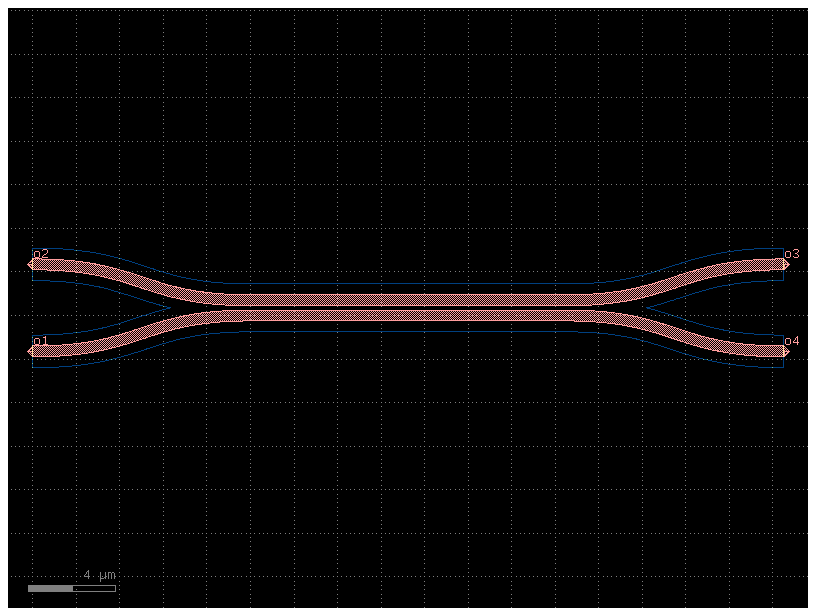

In [1]:
from ubcpdk import PDK, cells

PDK.activate()

c = cells.coupler()

cc = c.copy()
cc.draw_ports()
cc

### Configure Palace driven simulation with waveports

In [2]:
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-dc-waveport")
sim.set_geometry(c)

sim.set_stack(
    air_above=3.0,
    air_below=3.0,
    substrate_thickness=2.0,
    add_oxide_dielectric=False,
    add_passivation_dielectric=False,
)

for i, port in enumerate(c.ports):
    sim.add_wave_port(
        port.name,
        layer="core",
        z_margin=1.0,
        lateral_margin=1.0,
        max_size=False,
        mode=1,
        excited=(i == 0),
    )

# Around 1.55 um (~193.5 THz).
sim.set_driven(fmin=190e12, fmax=200e12, num_points=21)

print(sim.validate_config())

Validation: PASSED


In [3]:
import gdsfactory as gf

active = gf.get_active_pdk()
print("Active PDK:", active.name)

stack = sim._resolve_stack()
print("Stack layers:")
for name, layer in stack.layers.items():
    print(
        f"  - {name}: type={layer.layer_type}, material={layer.material}, "
        f"gds={tuple(layer.gds_layer)}, z=({layer.zmin}, {layer.zmax})"
    )

print("\nMaterial properties (selected):")
for key in ("si", "sio2", "SiO2", "air"):
    if key in stack.materials:
        print(f"  - {key}: {stack.materials[key]}")

print("\nDielectric regions:")
for d in stack.dielectrics:
    print(f"  - {d}")

Active PDK: ubcpdk
Stack layers:
  - box: type=dielectric, material=sio2, gds=(999, 0), z=(-3.0, 0.0)
  - clad: type=dielectric, material=sio2, gds=(999, 0), z=(0.0, 1.8000000000000003)
  - core: type=dielectric, material=si, gds=(1, 0), z=(0.0, 0.22)
  - core2: type=dielectric, material=si, gds=(31, 0), z=(0.0, 0.22)
  - heater: type=conductor, material=TiN, gds=(11, 0), z=(1.1, 1.85)
  - metal2: type=conductor, material=Aluminum, gds=(12, 0), z=(1.8000000000000003, 2.5000000000000004)

Material properties (selected):
  - si: {'type': 'semiconductor', 'conductivity': 2.0, 'permittivity': 11.9, 'refractive_index': 3.47}
  - sio2: {'type': 'dielectric', 'permittivity': 4.1, 'loss_tangent': 0.0, 'refractive_index': 1.44}
  - SiO2: {'type': 'dielectric', 'permittivity': 4.1, 'loss_tangent': 0.0, 'refractive_index': 1.44}
  - air: {'type': 'dielectric', 'permittivity': 1.0, 'loss_tangent': 0.0, 'refractive_index': 1.0}

Dielectric regions:
  - {'name': 'air_box', 'zmin': 2.5000000000000004

### Generate mesh

In [4]:
sim.mesh(
    preset="fine",
    refined_mesh_size=1.0,
    max_mesh_size=40.0,
    fmax=220e12,
    margin_x=1.0,
    margin_y=1.0,
    airbox_margin=0.0,
    curve_fit_mode="bspline",
    curve_fit_layers=["core", "core2"],
    curve_fit_tolerance_um=0.01,
    curve_fit_min_points=8,
    high_order_elements=True,
    high_order_order=2,
    high_order_optimize=True,
)

Mesh Summary
Dimensions: 36.5 x 6.5 x 10.5 µm
Nodes:      2,900
Elements:   2,766
----------------------------------------
Volumes (2):
  - core [1]
  - air [2]
Surfaces (6):
  - P1 [3]
  - P2 [4]
  - P3 [5]
  - P4 [6]
  - core__None [7]
  - air__None [8]
----------------------------------------
Mesh:   palace-sim-dc-waveport/palace.msh

In [5]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None"],
    interactive=True,
)

Widget(value='<iframe src="http://localhost:35183/index.html?ui=P_0x73fd791605f0_0&reconnect=auto" class="pyvi…

### Run simulation

In [6]:
for p in sim._last_mesh_result.port_info:
    print(
        f"{p['type']} P{p['portnumber']}: "
        f"z=({p['zmin']:.3f}, {p['zmax']:.3f}), "
        f"x=({p['xmin']:.3f}, {p['xmax']:.3f}), "
        f"y=({p['ymin']:.3f}, {p['ymax']:.3f})"
    )

waveport P1: z=(-1.000, 1.220), x=(-10.000, -10.000), y=(-2.900, -0.400)
waveport P2: z=(-1.000, 1.220), x=(-10.000, -10.000), y=(1.100, 3.600)
waveport P3: z=(-1.000, 1.220), x=(24.500, 24.500), y=(1.100, 3.600)
waveport P4: z=(-1.000, 1.220), x=(24.500, 24.500), y=(-2.900, -0.400)


In [7]:
results = sim.run()

ValueError: Mesh validation failed:
Validation: FAILED
Errors:
  - No conductor surfaces in mesh. Check that conductor layers have polygons and correct layer_type.
  - config.json has no Conductivity or PEC boundaries.
Warnings:
  - Volumes: ['air', 'core']

### Plot S-parameters

In [ ]:
results.plot_interactive()

In [ ]:
results.plot_interactive(phase=True)